<div style="background:linear-gradient(135deg,#172554 0%,#1e40af 55%,#3b82f6 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#bfdbfe;font-weight:700;text-transform:uppercase">Chapter 73 · Estimation &amp; Confidence Intervals</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Resampling &amp; Simulation 🔁</div>
  <div style="font-size:15px;color:#eff6ff;max-width:740px;line-height:1.6">When no formula exists, let the data resample itself. The bootstrap builds a confidence interval for almost any statistic by drawing samples-of-the-sample. We validate it against the t-interval, then put a CI on a real MEDIAN salary, where no simple formula exists.</div>
  <div style="margin-top:16px;font-size:13px;color:#bfdbfe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
BLUE="#2563eb"; DEEP="#1d4ed8"; LIGHT="#60a5fa"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; PINK="#db2777"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
rng = np.random.default_rng(73)

<div style="background:#eef2ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">BEAT 1 · THE BOOTSTRAP IDEA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Resample the sample, with replacement</div>
<div style="color:#4a5578;margin-top:6px">We only have one sample, but we can mimic 'drawing many samples' by resampling FROM our sample with replacement. Each resample is the same size; recompute the statistic each time to build its bootstrap distribution.</div>
</div>

In [2]:
data = rng.normal(50, 10, 60)        # our one sample
def bootstrap(x, stat=np.mean, B=10000):
    n=len(x); idx=rng.integers(0, n, size=(B, n))
    return stat(x[idx], axis=1)
boot_means = bootstrap(data, np.mean)
print(f"original sample mean = {data.mean():.2f}")
print(f"bootstrap distribution of the mean: center {boot_means.mean():.2f}, spread (= SE) {boot_means.std():.3f}")
print(f"formula SE = s/sqrt(n) = {data.std(ddof=1)/np.sqrt(60):.3f}  (the bootstrap recovers it with no formula)")

original sample mean = 49.67
bootstrap distribution of the mean: center 49.68, spread (= SE) 1.270
formula SE = s/sqrt(n) = 1.284  (the bootstrap recovers it with no formula)


The spread of the bootstrap distribution <em>is</em> the standard error, recovered without any formula. The bootstrap turns "imagine resampling the population" into "actually resample the sample", and it works because a good sample resembles the population it came from.

<div style="background:#eef2ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">BEAT 2 · THE PERCENTILE INTERVAL</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Read the CI straight off the bootstrap distribution</div>
<div style="color:#4a5578;margin-top:6px">The simplest bootstrap CI is the percentile method: take the 2.5th and 97.5th percentiles of the bootstrap statistics. For a mean, this should agree closely with the textbook t-interval, a good sanity check.</div>
</div>

In [3]:
lo, hi = np.percentile(boot_means, [2.5, 97.5])
print(f"bootstrap 95% percentile CI for the mean: [{lo:.2f}, {hi:.2f}]")
se=data.std(ddof=1)/np.sqrt(60); t=stats.t.ppf(0.975,59)
tlo,thi = data.mean()-t*se, data.mean()+t*se
print(f"classic t-interval for the mean:          [{tlo:.2f}, {thi:.2f}]")
print("-> they agree: the bootstrap reproduces the formula answer for the mean")

bootstrap 95% percentile CI for the mean: [47.18, 52.17]
classic t-interval for the mean:          [47.10, 52.24]
-> they agree: the bootstrap reproduces the formula answer for the mean


For the mean, the bootstrap and the t-interval give essentially the same answer, exactly what we want for a method that should generalize the formula. The payoff comes when there <em>is</em> no formula.

<div style="background:#eef2ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">BEAT 3 · WHERE THE BOOTSTRAP WINS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A CI for the median (no formula)</div>
<div style="color:#4a5578;margin-top:6px">The median has no simple standard-error formula. The bootstrap does not care: resample, take the median each time, read off the percentiles. The same three lines that handled the mean now handle the median.</div>
</div>

In [4]:
skewed = rng.lognormal(4, 0.5, 200)   # right-skewed data
boot_med = bootstrap(skewed, np.median)
lo, hi = np.percentile(boot_med, [2.5, 97.5])
print(f"sample median = {np.median(skewed):.2f}")
print(f"bootstrap 95% CI for the MEDIAN: [{lo:.2f}, {hi:.2f}]  (no formula needed)")
# the same machinery works for ANY statistic, e.g. the 90th percentile or a trimmed mean
b90 = bootstrap(skewed, lambda a,axis: np.percentile(a,90,axis=axis))
print(f"bootstrap 95% CI for the 90th percentile: [{np.percentile(b90,2.5):.1f}, {np.percentile(b90,97.5):.1f}]")

sample median = 53.47
bootstrap 95% CI for the MEDIAN: [49.75, 58.99]  (no formula needed)
bootstrap 95% CI for the 90th percentile: [90.0, 119.6]


No new theory, no new formula, the same resample-and-recompute loop delivers a confidence interval for the median, a percentile, a correlation, a ratio, anything you can compute. This generality is why the bootstrap (Efron, 1979) is one of the most useful tools in modern statistics.

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">REAL-WORLD EXAMPLE · SALARIES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A confidence interval for the median salary</div>
<div style="color:#4a5578;margin-top:6px"></div>
</div>

An HR team exports <strong>300 employee salaries</strong> (`ch73_salaries.xlsx`). Pay is right-skewed (a few high earners), so the median is the fairer summary, but it has no neat CI formula. The bootstrap handles it directly.

In [5]:
try:    emp = pd.read_excel("../../data/ch73_salaries.xlsx", sheet_name="Employees")
except FileNotFoundError: emp = pd.read_excel(BASE+"ch73_salaries.xlsx", sheet_name="Employees")
print("loaded:", emp.shape)
sal = emp["annual_salary"].values
print(f"n={len(sal)}, mean=${sal.mean():,.0f}, median=${np.median(sal):,.0f}, skew={stats.skew(sal):.2f} (right-skewed)")

loaded: (300, 4)
n=300, mean=$111,251, median=$107,650, skew=0.85 (right-skewed)


In [6]:
boot_med = bootstrap(sal, np.median, B=20000)
mlo, mhi = np.percentile(boot_med, [2.5, 97.5])
print(f"BOOTSTRAP 95% CI for the MEDIAN salary: [${mlo:,.0f}, ${mhi:,.0f}]  (point ${np.median(sal):,.0f})")
# compare to the normal-theory CI for the MEAN
se=sal.std(ddof=1)/np.sqrt(len(sal)); t=stats.t.ppf(0.975,len(sal)-1)
print(f"t-interval 95% CI for the MEAN salary:   [${sal.mean()-t*se:,.0f}, ${sal.mean()+t*se:,.0f}]  (point ${sal.mean():,.0f})")

BOOTSTRAP 95% CI for the MEDIAN salary: [$101,050, $111,100]  (point $107,650)
t-interval 95% CI for the MEAN salary:   [$107,335, $115,167]  (point $111,251)


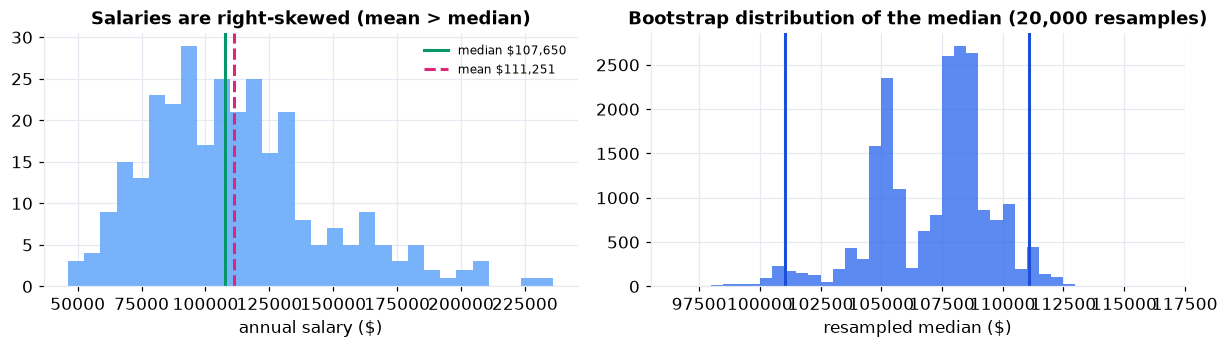

In [7]:
fig,ax=plt.subplots(1,2,figsize=(11,3.3))
ax[0].hist(sal, bins=30, color=LIGHT, alpha=0.85)
ax[0].axvline(np.median(sal),color=GREEN,lw=2,label=f"median ${np.median(sal):,.0f}")
ax[0].axvline(sal.mean(),color=PINK,lw=2,ls="--",label=f"mean ${sal.mean():,.0f}")
ax[0].set_title("Salaries are right-skewed (mean > median)"); ax[0].set_xlabel("annual salary ($)"); ax[0].legend(fontsize=8)
ax[1].hist(boot_med, bins=40, color=BLUE, alpha=0.75)
ax[1].axvline(mlo,color=DEEP,lw=2); ax[1].axvline(mhi,color=DEEP,lw=2)
ax[1].set_title("Bootstrap distribution of the median (20,000 resamples)"); ax[1].set_xlabel("resampled median ($)")
plt.tight_layout(); plt.show()

The median salary is about <strong>$107,650</strong>, with a bootstrap 95% interval of roughly <strong>$101,000 to $111,000</strong>, a defensible "typical pay" range that no textbook formula could provide. Because pay is right-skewed, the mean ($111,251) sits above the median; reporting the median with a bootstrap interval is the honest, robust summary. The bootstrap turned an awkward statistic into a routine one.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ Resampling, and the end of Part XI</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">The bootstrap resamples the sample with replacement to build the distribution of any statistic; its spread is the standard error, and its 2.5th/97.5th percentiles are a 95% CI. It reproduces the t-interval for the mean and, crucially, gives a CI for statistics with no formula, like the median salary (~$108k, 95% CI ~$101k-$111k). With estimation complete, Part XII turns to its mirror image: hypothesis testing.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>